# **10. Explicabilidad del Machine Learning**

## **10.1. Importancia en la permutación**
Es importante comparado con las otras opciones ya que es rapido de calcular, es muy usada para entender el modelo y es consistente con las propiedades que queriamos tener en una caracteristica de medición de importancia.

### **10.1.1. Como funciona**
*Despues de que el modelo sea ajustado*, se tienen columnas con datos como en la siguiente tabla:

![imagen](./images/importanciaPermutacionTabla1.png)

Entonces a continuación se cambian los valores de la columna de orden, así haciendo que el modelo se alimente de valores ''erroneos'', por lo tanto obtenemos un valor que permite medir el deterioro en el rendimiento por lo tanto obteniendo como de importante es dicha variable o columna que se ha permutado.

Y se prosigue de la siguiente forma, se vuelven a poner los valores en el orden que se tenian antes de la permutación actual, y se cambian los valores de la siguiente columna para comprobar de esta forma como afecta cada columna a el rendimiento del modelo.

![imagen](./images/importanciaPermutacionTabla2.png)

### **10.1.2. Ejemplo de la importancia de la permutación**
En nuestro ejemplo utilizaremos un modelo que predice si un equipo de fútbol tendrá al ganador del premio ''Jugador del partido'' basándose en las estadísticas del equipo. El premio ''Jugador del partido'' se otorga al mejor jugador del encuentro. La creación del modelo no es nuestro objetivo principal en este momento, por lo que la celda siguiente carga los datos y crea un modelo básico.

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = pd.read_csv('./FIFA 2018 Statistics.csv')
y = (data['Man of the Match'] == "Yes")  # Convert from string "Yes"/"No" to binary
feature_names = [i for i in data.columns if data[i].dtype in [np.int64]]
X = data[feature_names]
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
my_model = RandomForestClassifier(n_estimators=100,
                                  random_state=0).fit(train_X, train_y)

In [10]:
!pip install eli5
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(my_model, random_state=1).fit(val_X, val_y)
eli5.show_weights(perm, feature_names = val_X.columns.tolist())

Weight,Feature
0.1750 ± 0.0848,Goal Scored
0.0500 ± 0.0637,Distance Covered (Kms)
0.0437 ± 0.0637,Yellow Card
0.0187 ± 0.0637,Free Kicks
0.0187 ± 0.0500,Off-Target
0.0187 ± 0.0637,Fouls Committed
0.0125 ± 0.0637,Pass Accuracy %
0.0125 ± 0.0306,Blocked
0.0063 ± 0.0612,Saves
0.0063 ± 0.0250,Ball Possession %


Los valores situados en la parte superior son las características más importantes, y los de la parte inferior son los menos relevantes.

El primer número de cada fila indica en qué medida ha disminuido el rendimiento del modelo tras una reorganización aleatoria (en este caso, utilizando la ''precisión'' como métrica de rendimiento).

Como ocurre con la mayoría de los aspectos de la ciencia de datos, existe cierta aleatoriedad en el cambio exacto de rendimiento que se produce al barajar una columna. Medimos el grado de aleatoriedad en nuestro cálculo de la importancia de permutación repitiendo el proceso con múltiples barajadas. El número que aparece después del signo ± mide cómo varió el rendimiento de una barajada a la siguiente.

En ocasiones, verás valores negativos en las importancias de permutación. En esos casos, las predicciones sobre los datos reordenados (o con ruido) resultaron ser más precisas que las de los datos reales. Esto ocurre cuando la característica no era relevante (debería haber tenido una importancia cercana a 0), pero el azar hizo que las predicciones sobre los datos reordenados fueran más precisas. Esto es más habitual con conjuntos de datos pequeños, como el de este ejemplo, ya que hay más margen para la suerte o el azar.

En nuestro ejemplo, la característica más importante fue ''Goles marcados''. Esto parece lógico. Los aficionados al fútbol pueden tener cierta intuición sobre si el orden de las demás variables resulta sorprendente o no.

## **10.2. Graficos de dependencias parciales (Partial Plots)**
Tambien despues de que el modelo sea ajustado, en este caso se altera un valor (columna) repetdiamente para hacer una seria de predicciones, asi obteniendo las variaciones entre las distintas respuestas que prevee el modelo.'

### **10.2.1. Ejemplo de graficos de dependencias parciales**
En este ejemplo no se centra en explicar la construcción del modelo si no en la exploración de los datos que le adjunto al modelo.

In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

data = pd.read_csv('./FIFA 2018 Statistics.csv')
y = (data['Man of the Match'] == "Yes")  # Convert from string "Yes"/"No" to binary
feature_names = [i for i in data.columns if data[i].dtype in [np.int64]]
X = data[feature_names]
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
tree_model = DecisionTreeClassifier(random_state=0, max_depth=5, min_samples_split=5).fit(train_X, train_y)


El siguiente grafico es un árbol de decisiones, es un modelo pequeño por lo tanto la predicción es facil de interpretar, en modelos mas grandes este árbol crece exponencialmente.

Indicaciones para interpretar el árbol:

- Las hojas con subárboles muestran su criterio de división en la parte superior.
- El par de valores de la parte inferior indica el número de valores ''Falso'' y ''Verdadero'' para el objetivo, respectivamente, de los puntos de datos de ese nodo del árbol.

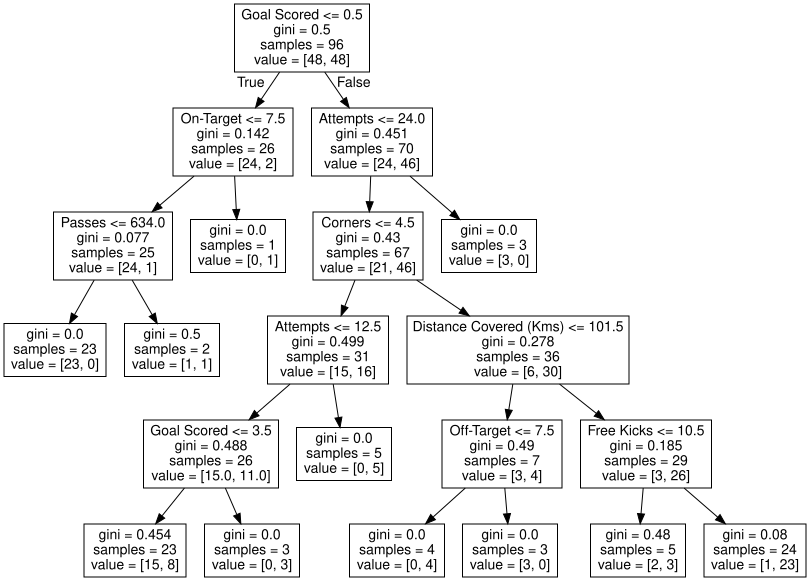

In [27]:
from sklearn import tree
import graphviz

tree_graph = tree.export_graphviz(tree_model, out_file=None, feature_names=feature_names)
graphviz.Source(tree_graph)


A continuación se muestra el código para crear el gráfico de dependencia parcial utilizando la biblioteca scikit-learn.

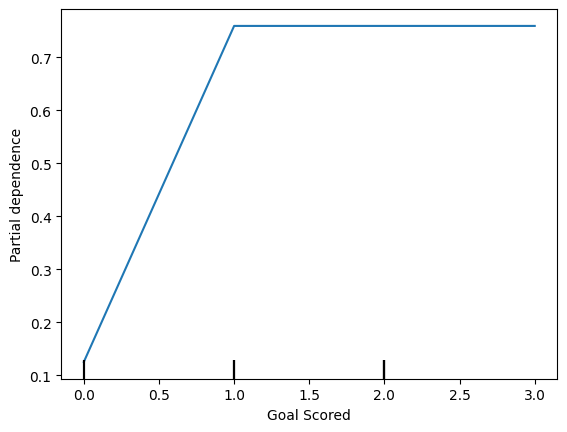

In [28]:
from matplotlib import pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Create and plot the data
disp1 = PartialDependenceDisplay.from_estimator(tree_model, val_X, ['Goal Scored'])
plt.show()

El eje Y se interpreta como la variación en la predicción con respecto a lo que se habría pronosticado en el valor de referencia o en el valor situado más a la izquierda.

En este gráfico concreto, vemos que marcar un gol aumenta considerablemente las posibilidades de ser elegido ''Jugador del partido''. Sin embargo, los goles adicionales más allá de ese punto parecen tener poco impacto en las predicciones.

Aquí hay otro gráfico de ejemplo:

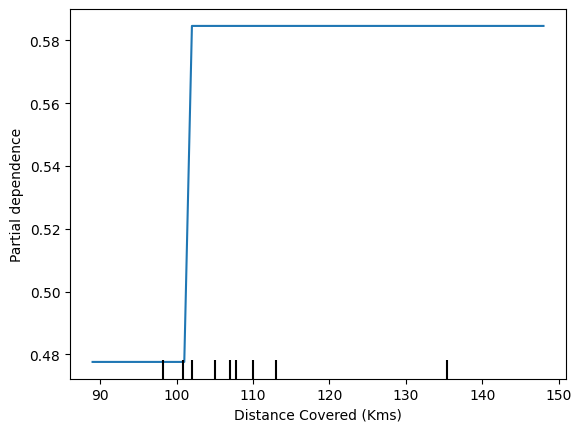

In [30]:
feature_to_plot = 'Distance Covered (Kms)'
disp2 = PartialDependenceDisplay.from_estimator(tree_model, val_X, [feature_to_plot])
plt.show()


Este gráfico parece demasiado sencillo para reflejar la realidad. Pero eso se debe a que el modelo es muy sencillo. En el árbol de decisión anterior se puede apreciar que representa exactamente la estructura del modelo.

Se puede comparar fácilmente la estructura o las implicaciones de diferentes modelos. Aquí tienes el mismo gráfico con un modelo de ''Random Forest''.

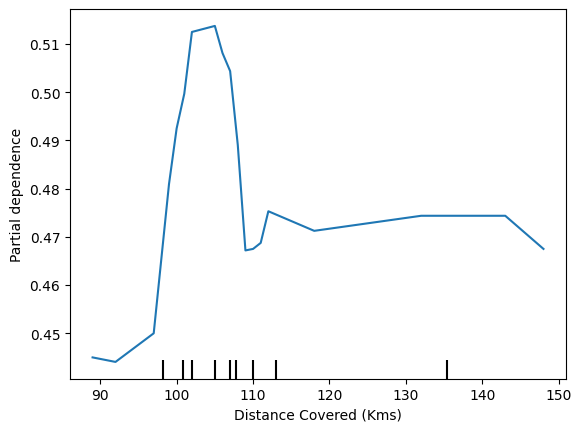

In [31]:
# Build Random Forest model
rf_model = RandomForestClassifier(random_state=0).fit(train_X, train_y)

disp3 = PartialDependenceDisplay.from_estimator(rf_model, val_X, [feature_to_plot])
plt.show()

Muestra el siguiente gráfico las interacciones entre las características.

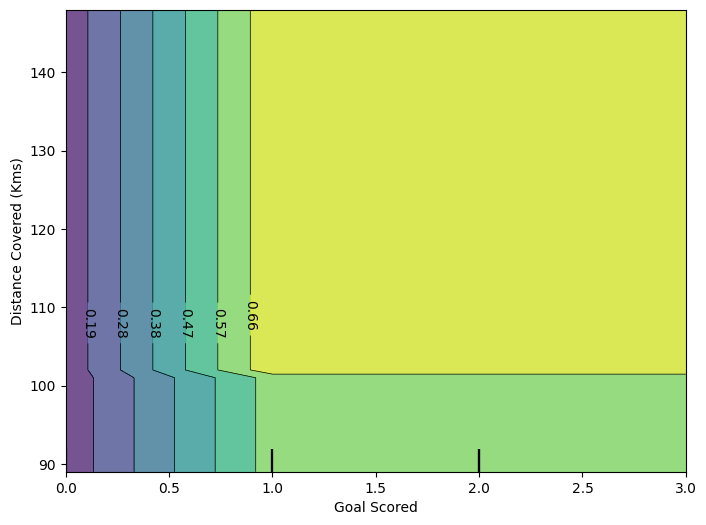

In [33]:
ig, ax = plt.subplots(figsize=(8, 6))
f_names = [('Goal Scored', 'Distance Covered (Kms)')]
# Similar to previous PDP plot except we use tuple of features instead of single feature
disp4 = PartialDependenceDisplay.from_estimator(tree_model, val_X, f_names, ax=ax)
plt.show()

## **10.3. Valores SHAP**
Los valores SHAP (SHapley Additive exPlanations) explican el porque de las decisiones individuales sobre un caso que hace el modelo.

Los valores SHAP lo hacen de una forma que garantiza una propiedad interesante. En concreto, se descompone una predicción con la siguiente ecuación:

```Python
sum(SHAP values for all features) = pred_for_team - pred_for_baseline_values
```

Es decir, la suma de los valores SHAP de todas las características explica por qué mi predicción fue diferente de la de referencia. Esto nos permite descomponer una predicción en un gráfico como este:

![imagen](./images/SHAPVAluesTable.png)

**¿Cómo se interpreta esto?**

Predijimos 0,7, mientras que el valor de referencia (base_value) es 0,4979. Los valores de las características que provocan un aumento de las predicciones aparecen en rosa, y su tamaño visual muestra la magnitud del efecto de la característica. Los valores de las características que reducen la predicción aparecen en azul. El mayor impacto proviene de ''Goles marcados'', que es 2. Aunque el valor de la posesión del balón tiene un efecto significativo a la hora de reducir la predicción.

Si restas la longitud de las barras azules de la longitud de las barras rosas, el resultado es igual a la distancia entre el valor base y el resultado.

La técnica presenta cierta complejidad, ya que hay que garantizar que la línea de base más la suma de los efectos individuales dé como resultado la predicción (lo cual no es tan sencillo como parece).